# Do adopters already speak the partner language?

**Adopter-level test of the absorptive-capacity mechanism behind the D2 host-share effect** (screen fold only;
*mechanism evidence, not confirmation*).

The D2 result says: when a concept `c` enters a new host subfield `d`, entries whose partner concepts are already
well-anchored in the host (high `A_cont`) get adopted more. This evaluation asks *who* adopts. It builds matched
case-control strata:

* **case** = a newcomer author who adopts `c` in `d` within 5 years of entry `e` (author-disjoint from the entry papers),
* **control(s)** = incidence-density risk-set authors from the same host and adoption year, exact-matched on prior works,
  team size, activity and first year,

and then tests with **conditional logistic regression** whether adopters had *already used the entry's partner concepts*
in their own prior work (`E_any`) more than matched controls — net of a matched negative-control vocabulary (`E_neg`),
placebo partners from another entry (`E_plac`), and prior output (`lp`). Uncertainty comes from a concept-cluster bootstrap.

**What this notebook runs.** The original `eval.py` has stages `prepare → frame → freeze → pull → analyze`. The first
stages need the multi-GB OpenAlex corpus, so the demo starts from the frozen, already-computed exposure table and re-runs
the **`analyze` stage's statistics** (model suite M-i/M-ii/M-iii, bootstrap, ratios, balance, permutation null,
statsmodels/pyfixest cross-checks, supplementary subsets, pre-declared reading rules) on a 100-stratum subset.
The helper functions from `src/stats_core.py` and `src/analysis.py` are copied verbatim.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, pyfixest — NOT on Colab, always install
_pip('loguru==0.7.3', 'pyfixest==0.60.0')

# numpy, pandas, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

## Imports
The original import block of `eval.py` / `src/analysis.py` / `src/stats_core.py`. `mech_common` (paths, corpus loaders,
vendored exp_7 code) is not needed for the analysis statistics; the two constants the analysis reads from it
(`SEED`, `LABEL`) and its `dump` helper are provided by a small stand-in namespace in the config cell.

In [2]:
from __future__ import annotations

import argparse
import hashlib
import re
import json
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
import logging

logging.getLogger("fontTools").setLevel(logging.WARNING)

## Data loading
Loads `mini_demo_data.json` from GitHub (Colab) or the local copy next to the notebook.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-4/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
print(meta["description"])
print(f"{meta['n_strata']} strata, {meta['n_rows']} author rows")

100 matched sets (1 adopter case + 1 control + up to 2 reserve controls) sampled (seed 20260929) evenly across A_cont terciles from the 1,013 primary strata. Exposure columns E_* were computed by the original compute_exposures() from the (large) OpenAlex corpus, which is not shipped with the demo.
100 strata, 355 author rows


## Config
All tunable parameters. `eval.py` ran `--stage analyze` with `B=1000` bootstrap replicates (`mini=False`), which gives
200 permutation draws and `max(B // 5, 50)` replicates for each supplementary subset. The `--mini` smoke run used
`B=20`, 50 permutations and 20 supplementary replicates. `N_STRATA` limits how many of the 100 shipped strata are used.

In [5]:
mini = False      # original full run: False  (--mini smoke run: True -> 50 permutations, 20 supplementary reps)
B = 1000          # original: 1000 concept-cluster bootstrap replicates (--mini: 20)
N_STRATA = 100    # strata used from mini_demo_data.json (max 100 shipped; the full primary frame has 1,013)

# stand-in for the parts of src/mech_common.py the analysis uses
def _default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if np.isnan(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (set, tuple)):
        return list(o)
    if isinstance(o, Path):
        return str(o)
    return str(o)


def _dump(obj, p: Path) -> None:
    Path(p).write_text(json.dumps(obj, indent=1, default=_default))


mc = SimpleNamespace(SEED=meta["SEED"], LABEL="screen-fold mechanism evidence, not confirmation", dump=_dump,
                     RESULTS=Path("demo_results"))
mc.RESULTS.mkdir(exist_ok=True)

## Statistical core (`src/stats_core.py`, verbatim)
* `clogit` — Newton-Raphson conditional logistic regression (one case per stratum, any number of controls), with
  model-based SEs and concept-cluster-robust (CRV) SEs from per-stratum scores.
* `boot_indices` — concept-cluster bootstrap draw (whole concepts are resampled, so all strata of a concept move together).
* `pct_ci`, `boot_p`, `wald_p`, `smd`, `kappa` — percentile CI, two-sided bootstrap p, Wald p, standardized mean
  difference, Cohen's kappa.

In [6]:
def clogit(y: np.ndarray, X: np.ndarray, strata: np.ndarray, cluster: np.ndarray | None = None,
           maxit: int = 50, tol: float = 1e-10) -> dict:
    """Conditional logistic regression. y: 0/1 case flag (one case per stratum), X: n x k, strata: int ids."""
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    _, s = np.unique(strata, return_inverse=True)
    ns = s.max() + 1
    k = X.shape[1]
    beta = np.zeros(k)
    ll_old = -np.inf
    conv = False
    for it in range(maxit):
        eta = X @ beta
        # stabilise per stratum
        mx = np.full(ns, -np.inf)
        np.maximum.at(mx, s, eta)
        ex = np.exp(eta - mx[s])
        den = np.bincount(s, weights=ex, minlength=ns)
        p = ex / den[s]
        ll = float(np.sum(eta[y == 1] - mx[s[y == 1]] - np.log(den[s[y == 1]])))
        xbar = np.zeros((ns, k))
        np.add.at(xbar, s, p[:, None] * X)
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        grad = (casex - xbar).sum(0)
        dev = X - xbar[s]
        H = (dev * p[:, None]).T @ dev
        try:
            step = np.linalg.solve(H + 1e-10 * np.eye(k), grad)
        except np.linalg.LinAlgError:
            break
        beta = beta + step
        if abs(ll - ll_old) < tol and np.max(np.abs(step)) < 1e-7:
            conv = True
            break
        ll_old = ll
    eta = X @ beta
    mx = np.full(ns, -np.inf)
    np.maximum.at(mx, s, eta)
    ex = np.exp(eta - mx[s])
    den = np.bincount(s, weights=ex, minlength=ns)
    p = ex / den[s]
    xbar = np.zeros((ns, k))
    np.add.at(xbar, s, p[:, None] * X)
    dev = X - xbar[s]
    H = (dev * p[:, None]).T @ dev
    try:
        Hi = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        Hi = np.full((k, k), np.nan)
    se = np.sqrt(np.clip(np.diag(Hi), 0, None))
    out = {"beta": beta, "se": se, "converged": conv, "n_strata": int(ns), "n": int(len(y))}
    if cluster is not None:
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        score_s = casex - xbar  # per-stratum score
        cl_s = np.zeros(ns, dtype=np.int64)
        _, cl = np.unique(cluster, return_inverse=True)
        cl_s[s] = cl
        G = cl.max() + 1
        S = np.zeros((G, k))
        np.add.at(S, cl_s, score_s)
        V = G / (G - 1) * Hi @ (S.T @ S) @ Hi if G > 1 else Hi
        out["se_crv"] = np.sqrt(np.clip(np.diag(V), 0, None))
        out["G"] = int(G)
    return out


def boot_indices(cluster_of_row: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Concept-cluster bootstrap: returns row indices and a replicate-cluster id per row (duplicates distinct)."""
    uc, inv = np.unique(cluster_of_row, return_inverse=True)
    rows_by = [np.flatnonzero(inv == i) for i in range(len(uc))]
    draw = rng.integers(0, len(uc), len(uc))
    idx = np.concatenate([rows_by[j] for j in draw])
    rep = np.concatenate([np.full(len(rows_by[j]), t) for t, j in enumerate(draw)])
    return idx, rep


def pct_ci(x: np.ndarray, alpha: float = 0.05) -> list[float]:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return [float("nan"), float("nan")]
    return [float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))]


def boot_p(x: np.ndarray, null: float = 0.0) -> float:
    """Two-sided bootstrap p: 2 x min share of replicates on either side of the null (floored at 1/(B+1))."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return float("nan")
    p = 2 * min((x <= null).mean(), (x >= null).mean())
    return float(max(min(p, 1.0), 1 / (len(x) + 1)))


def wald_p(b: float, se: float) -> float:
    return float(2 * stats.norm.sf(abs(b / se))) if se and np.isfinite(se) and se > 0 else float("nan")


def smd(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / sd) if sd > 0 else 0.0


def kappa(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, int), np.asarray(b, int)
    po = (a == b).mean()
    pe = a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean())
    return float((po - pe) / (1 - pe)) if pe < 1 else float("nan")

## Model set and concept-cluster bootstrap (`src/analysis.py`, verbatim)
`MODELS` lists every pre-declared conditional-logit specification:

| model | question |
|---|---|
| `m2` (**primary**) | OR of prior partner use `E_any`, net of the negative-control vocabulary `E_neg` and prior output `lp` |
| `m_plac` / `m_plac_only` | does partner use beat placebo partners of another entry into the same host? |
| `m_swap` | label shuffle: the other entry's full partner set (should be ~1) |
| `m_int` | interaction `E_any × z(A_cont)` — is enrichment stronger in well-anchored entries? |
| `m_voc` | which partner class drives it: NATIVE / ADJACENT / FOREIGN (by pre-entry host share) |
| `m_comp` | origin-companion partners vs the rest |

`fit_model` drops columns with no within-stratum variation; `bootstrap` resamples concepts and refits the whole suite
(`model_suite`) per replicate; `ratio_summary` turns bootstrap draws of a log-OR difference into ratio CIs.

In [7]:
MODELS = {
    "m1": ["E_any", "lp"],
    "m2": ["E_any", "E_neg", "lp"],                      # PRIMARY estimand: OR(E_any | E_neg, prior_n)
    "m3": ["E_w", "E_neg", "lp"],
    "m_neg_only": ["E_neg", "lp"],
    "m_plac": ["E_any", "E_neg", "E_plac", "lp"],        # strata with a placebo entry only
    "m_plac_only": ["E_plac", "lp"],                     # strata with a placebo entry only
    "m_int": ["E_any", "E_neg", "lp", "E_any_x_zA"],
    "m_voc": ["E_nat", "E_adj", "E_for", "E_unprof", "E_neg", "lp"],
    "m_comp": ["E_comp", "E_noncomp", "E_neg", "lp"],
    "m_swap": ["E_swap", "E_neg", "lp"],                 # label shuffle: another entry's partner set, same host-year
    "m_any_incl_c": ["E_any_incl_c", "E_neg", "lp"],
}
PLAC_MODELS = {"m_plac", "m_plac_only", "m_swap"}


def add_design(D: pd.DataFrame, sdA: float, mA: float) -> pd.DataFrame:
    D = D.copy()
    D["lp"] = np.log1p(D.n_prior_corpus.astype(float))
    D["zA"] = (D.A_cont - mA) / sdA
    D["E_any_x_zA"] = D.E_any * D.zA
    return D


# ------------------------------------------------------------------ model set + bootstrap
def fit_model(D: pd.DataFrame, cols: list[str], cluster: bool = True) -> dict | None:
    X = D[cols].to_numpy(float)
    keep = np.ones(len(cols), bool)
    # drop exposure columns without any within-stratum variation (unidentified)
    s = D.stratum.to_numpy()
    for j in range(len(cols)):
        mx = pd.Series(X[:, j]).groupby(s).agg(lambda z: z.max() - z.min())
        if (mx > 0).sum() == 0:
            keep[j] = False
    if keep.sum() == 0:
        return None
    r = clogit(D.case.to_numpy(), X[:, keep], s, D.cluster.to_numpy() if cluster else None)
    beta = np.full(len(cols), np.nan)
    se = np.full(len(cols), np.nan)
    sec = np.full(len(cols), np.nan)
    beta[keep], se[keep] = r["beta"], r["se"]
    if cluster:
        sec[keep] = r["se_crv"]
    return {"cols": cols, "beta": beta, "se": se, "se_crv": sec, "n_strata": r["n_strata"], "n": r["n"],
            "converged": r["converged"]}


def fast_betas(D: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X = D[cols].to_numpy(float)
    try:
        r = clogit(D.case.to_numpy(), X, D.stratum.to_numpy(), None, maxit=30)
        b = r["beta"]
        b[np.abs(b) > 15] = np.nan  # separation in a replicate
        return b
    except (np.linalg.LinAlgError, FloatingPointError, ValueError):
        return np.full(len(cols), np.nan)


def model_suite(D: pd.DataFrame) -> dict:
    out = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        out[name] = fast_betas(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        out[f"m2_T{t}"] = fast_betas(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else np.full(3, np.nan)
    return out


def bootstrap(D: pd.DataFrame, B: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    st = D.drop_duplicates("stratum")[["stratum", "cluster"]]
    rows_by_stratum = D.groupby("stratum").indices
    reps = {}
    for b in range(B):
        sidx, rep = boot_indices(st.cluster.to_numpy(), rng)
        chosen = st.stratum.to_numpy()[sidx]
        parts, sid = [], []
        for k, s_ in enumerate(chosen):
            ix = rows_by_stratum[s_]
            parts.append(ix)
            sid.append(np.full(len(ix), k))
        ix = np.concatenate(parts)
        Db = D.iloc[ix].copy()
        Db["stratum"] = np.concatenate(sid)
        res = model_suite(Db)
        for k, v in res.items():
            reps.setdefault(k, []).append(v)
    return {k: np.vstack(v) for k, v in reps.items()}


def bootstrap_one(D: pd.DataFrame, cols: list[str], B: int, seed: int) -> np.ndarray:
    """Concept-cluster bootstrap for a single model (same resampling scheme as bootstrap())."""
    rng = np.random.default_rng(seed)
    st = D.drop_duplicates("stratum")[["stratum", "cluster"]]
    rows_by_stratum = D.groupby("stratum").indices
    out = []
    for _ in range(B):
        sidx, _rep = boot_indices(st.cluster.to_numpy(), rng)
        chosen = st.stratum.to_numpy()[sidx]
        ix = np.concatenate([rows_by_stratum[s_] for s_ in chosen])
        sid = np.concatenate([np.full(len(rows_by_stratum[s_]), k) for k, s_ in enumerate(chosen)])
        Db = D.iloc[ix].copy()
        Db["stratum"] = sid
        out.append(fast_betas(Db, cols))
    return np.vstack(out)


def summarize_model(name: str, fit: dict | None, boots: np.ndarray | None) -> dict:
    if fit is None:
        return {"model": name, "identified": False}
    out = {"model": name, "n_strata": fit["n_strata"], "n_rows": fit["n"], "converged": fit["converged"], "terms": {}}
    for j, c in enumerate(fit["cols"]):
        b = fit["beta"][j]
        term = {"beta": b, "OR": float(np.exp(b)) if np.isfinite(b) else None, "se_model": fit["se"][j],
                "se_crv_concept": fit["se_crv"][j], "p_model": wald_p(b, fit["se"][j]),
                "p_crv": wald_p(b, fit["se_crv"][j])}
        if boots is not None:
            bb = boots[:, j]
            ci = pct_ci(bb)
            term.update({"OR_ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
                         "p_boot": boot_p(bb), "boot_valid": int(np.isfinite(bb).sum())})
        out["terms"][c] = term
    return out


def ratio_summary(fit: dict, boots: np.ndarray, a: str, b: str) -> dict:
    ja, jb = fit["cols"].index(a), fit["cols"].index(b)
    est = fit["beta"][ja] - fit["beta"][jb]
    bb = boots[:, ja] - boots[:, jb]
    ci = pct_ci(bb)
    return {"log_ratio": est, "ratio": float(np.exp(est)) if np.isfinite(est) else None,
            "ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
            "p_boot": boot_p(bb), "log_contrast_ci95": ci}


def full_block(D: pd.DataFrame, B: int, seed: int) -> dict:
    """Point fits (with CRV SE) + concept-cluster bootstrap for the whole model suite."""
    fits = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        fits[name] = fit_model(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        fits[f"m2_T{t}"] = fit_model(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else None
    boots = bootstrap(D, B, seed) if B > 0 else {}
    summ = {k: summarize_model(k, f, boots.get(k)) for k, f in fits.items()}
    ratios = {}
    if fits["m2"] is not None and B > 0:
        ratios["partner_over_neg"] = ratio_summary(fits["m2"], boots["m2"], "E_any", "E_neg")
    if fits["m_plac"] is not None and B > 0:
        ratios["partner_over_plac"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_plac")
        ratios["partner_over_neg_in_plac_strata"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_neg")
    if fits["m_voc"] is not None and B > 0:
        ratios["native_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_nat", "E_for")
        ratios["adjacent_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_adj", "E_for")
    if fits["m_comp"] is not None and B > 0:
        ratios["companion_vs_noncompanion"] = ratio_summary(fits["m_comp"], boots["m_comp"], "E_comp", "E_noncomp")
    return {"fits": summ, "ratios": ratios, "_fits": fits, "_boots": boots}

## Descriptives, balance, permutation null and cross-checks (`src/analysis.py`, verbatim)
* `descriptives` — exposure prevalence among cases vs controls and discordant-pair counts.
* `balance` — SMDs of the matching variables after matching (and vs the full risk set before matching).
* `permutation_null` — reassigns the case label at random *within* each stratum and refits `m2`; the OR must centre on 1.
* `lpm_crosscheck` — linear probability model with stratum fixed effects (pyfixest, CRV1 by concept).
* `statsmodels_check` — the hand-written `clogit` against `statsmodels` `ConditionalLogit`.

In [8]:
def descriptives(D: pd.DataFrame) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {"n_cases": int(len(ca)), "n_controls": int(len(co)), "n_strata": int(D.stratum.nunique()),
           "n_concepts": int(D.cluster.nunique()), "n_entries": int(D.entry_id.nunique())}
    for c in ["E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for", "E_unprof", "E_comp", "E_noncomp", "E_swap",
              "E_any_incl_c"]:
        out[f"prev_case_{c}"] = float(ca[c].mean())
        out[f"prev_control_{c}"] = float(co[c].mean())
    out["mean_case_E_w"], out["mean_control_E_w"] = float(ca.E_w.mean()), float(co.E_w.mean())
    # discordant pairs (1:1)
    w = D.pivot_table(index="stratum", columns="case", values="E_any", aggfunc="max")
    out["discordant_case_only"] = int(((w[1] == 1) & (w[0] == 0)).sum())
    out["discordant_control_only"] = int(((w[1] == 0) & (w[0] == 1)).sum())
    out["discordant_pairs"] = out["discordant_case_only"] + out["discordant_control_only"]
    return out


def balance(D: pd.DataFrame, pre: pd.DataFrame | None) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {}
    for c in ["team_bin", "act_bin", "fy_bin", "prior_bin", "lp", "first_year"]:
        out[f"smd_after_{c}"] = smd(ca[c], co[c])
    if pre is not None and len(pre):
        for c, col in [("team_bin", "risk_team_bin_mean"), ("act_bin", "risk_act_bin_mean"),
                       ("prior_bin", "risk_prior_bin_mean"), ("lp", "risk_log1p_prior_mean")]:
            if col in pre:
                sd = np.sqrt((ca[c].var(ddof=1) + co[c].var(ddof=1)) / 2)
                out[f"smd_before_{c}"] = float((ca[c].mean() - pre[col].mean()) / sd) if sd > 0 else 0.0
    out["relax_counts"] = D[D.case == 1].relax.value_counts().sort_index().to_dict()
    return out


def permutation_null(D: pd.DataFrame, n: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    bs = []
    Dq = D.sort_values(["stratum", "case"]).copy()
    strata = Dq.stratum.to_numpy()
    for _ in range(n):
        u = rng.random(len(Dq))
        # within-stratum random reassignment of the single case label
        order = pd.Series(u).groupby(strata).rank(method="first").to_numpy()
        Dq["case"] = (order == 1).astype(int)
        bs.append(fast_betas(Dq, MODELS["m2"])[0])
    bs = np.array(bs)
    return {"n": n, "mean_logOR": float(np.nanmean(bs)), "sd_logOR": float(np.nanstd(bs)),
            "mean_OR": float(np.exp(np.nanmean(bs))), "q025_OR": float(np.exp(np.nanquantile(bs, 0.025))),
            "q975_OR": float(np.exp(np.nanquantile(bs, 0.975))), "draws": bs.tolist()}


def lpm_crosscheck(D: pd.DataFrame) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.feols("case ~ E_any + E_neg + lp | stratum", data=D.assign(stratum=D.stratum.astype(str)),
                     vcov={"CRV1": "cluster"})
    return {"coef_E_any": float(m.coef()["E_any"]), "se_E_any": float(m.se()["E_any"]),
            "p_E_any": float(m.pvalue()["E_any"]), "coef_E_neg": float(m.coef()["E_neg"]),
            "p_E_neg": float(m.pvalue()["E_neg"]), "n": int(m._N)}


def statsmodels_check(D: pd.DataFrame) -> dict:
    from statsmodels.discrete.conditional_models import ConditionalLogit
    m = ConditionalLogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), groups=D.stratum.to_numpy()).fit(disp=0)
    own = clogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), D.stratum.to_numpy())
    return {"sm_beta": m.params.tolist(), "own_beta": own["beta"].tolist(),
            "max_abs_diff": float(np.max(np.abs(m.params - own["beta"]))),
            "sm_se": m.bse.tolist(), "own_se": own["se"].tolist()}

## Build the analysis frame (replaces the parquet reads + `compute_exposures` of `stage_analyze`)
In `eval.py`, `stage_analyze` reads `frames/strata_long.parquet`, computes each member's exposures from the OpenAlex
corpus (`A.compute_exposures`), then adds the design columns. Here the exposures come precomputed in the demo data, so we
flatten the strata into the same long frame `L` and run the unchanged downstream lines (`cluster`, `add_design`,
`has_plac_stratum`). `mA`/`sdA` are the mean/SD of `A_cont` over all 1,544 co-primary entries (as in the original).

In [9]:
ex = data["examples"][:N_STRATA]
L = pd.DataFrame([m for x in ex for m in x["members"]])
pre = pd.DataFrame([x["risk_balance_pre"] for x in ex if x["risk_balance_pre"]])  # was frames/risk_balance_pre.parquet
mA, sdA = meta["entries_A_cont_mean"], meta["entries_A_cont_sd"]
power = meta["power"]  # frozen before exposure (mech_spec_power.json)
res = {"label": mc.LABEL, "exposure_label": "corpus-exposure, coverage-limited"}

L["cluster"] = L.concept_id
L = add_design(L, sdA, mA)
L["has_plac_stratum"] = L.groupby("stratum").has_plac.transform("max")
D = L[L.role.isin(["case", "control"])].copy()
print(L.role.value_counts().to_dict(), "| strata:", D.stratum.nunique(), "| concepts:", D.cluster.nunique())
D[["stratum", "role", "case", "concept_id", "A_tercile", "E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for", "lp"]].head(6)

{'case': 100, 'control': 100, 'reserve1': 84, 'reserve2': 71} | strata: 100 | concepts: 51


,stratum,role,case,concept_id,A_tercile,E_any,E_neg,E_plac,E_nat,E_adj,E_for,lp
0,1,case,1,c_007a7950eb4d,3,1,0,1,0,1,0,0.693147
1,1,control,0,c_007a7950eb4d,3,1,0,0,0,1,0,0.693147
4,12,case,1,c_029ea7c780b8,1,0,0,0,0,0,0,0.693147
5,12,control,0,c_029ea7c780b8,1,0,0,0,0,0,0,0.693147
8,26,case,1,c_05ffe8df405c,3,1,0,0,0,1,1,1.098612
9,26,control,0,c_05ffe8df405c,3,1,1,0,1,1,1,1.386294


## M-i / M-ii / M-iii: model suite + concept-cluster bootstrap
Straight from `stage_analyze`: fit every model, bootstrap `B` times, then collect enrichment (M-i), interaction and
per-tercile ORs (M-ii), vocabulary class (M-iii), the statsmodels/pyfixest checks, match balance and the attributable
fraction among exposed adopters.

In [10]:
t = time.time()
blk = full_block(D, B, mc.SEED + 11)
logger.info(f"primary model suite + bootstrap B={B} in {time.time() - t:.0f}s")
res["descriptives"] = descriptives(D)
res["enrichment"] = {k: blk["fits"][k] for k in ("m1", "m2", "m3", "m_neg_only", "m_plac", "m_plac_only", "m_swap",
                                                "m_any_incl_c")}
res["ratios"] = blk["ratios"]
res["interaction"] = {"m_int": blk["fits"]["m_int"], **{f"m2_T{t_}": blk["fits"][f"m2_T{t_}"] for t_ in (1, 2, 3)},
                      "tercile_MDE": power["pairs"]["tercile"]}
res["vocab_class"] = {"m_voc": blk["fits"]["m_voc"], "m_comp": blk["fits"]["m_comp"]}
res["checks"] = {"statsmodels": statsmodels_check(D), "lpm_pyfixest": lpm_crosscheck(D)}
res["match_balance"] = balance(D, pre)
m2 = blk["fits"]["m2"]["terms"]["E_any"]
pce = res["descriptives"]["prev_case_E_any"]
res["attributable_fraction_exposed"] = pce * (1 - 1 / m2["OR"]) if m2["OR"] else None

print("primary OR(E_any | NEG, prior):", round(m2["OR"], 3), m2.get("OR_ci95_boot"))
print("statsmodels max |beta diff|:", res["checks"]["statsmodels"]["max_abs_diff"])
print("LPM (pyfixest) coef E_any:", round(res["checks"]["lpm_pyfixest"]["coef_E_any"], 3))
print("balance:", {k: round(v, 3) for k, v in res["match_balance"].items() if k.startswith("smd")})

21:09:00|INFO   |primary model suite + bootstrap B=1000 in 10s


primary OR(E_any | NEG, prior): 2.329 [1.2456825412314982, 5.605856613447053]
statsmodels max |beta diff|: 0.0006010072442550474
LPM (pyfixest) coef E_any: 0.394
balance: {'smd_after_team_bin': -0.026, 'smd_after_act_bin': -0.021, 'smd_after_fy_bin': -0.084, 'smd_after_prior_bin': 0.0, 'smd_after_lp': -0.003, 'smd_after_first_year': -0.114, 'smd_before_team_bin': -0.175, 'smd_before_act_bin': -0.594, 'smd_before_prior_bin': -0.343, 'smd_before_lp': -0.341}


## Placebo / sanity: within-stratum permutation null
Shuffling which member is the case should give OR ≈ 1.

In [11]:
t = time.time()
res["permutation"] = permutation_null(D, 50 if mini else 200, mc.SEED + 13)
logger.info(f"permutation null in {time.time() - t:.0f}s")
print({k: v for k, v in res["permutation"].items() if k != "draws"})

21:09:01|INFO   |permutation null in 0s


{'n': 200, 'mean_logOR': 0.011859716762690785, 'sd_logOR': 0.40151898256449536, 'mean_OR': 1.01193032204702, 'q025_OR': 0.44880434261393076, 'q975_OR': 2.06318096006158}


## Supplementary robustness
From `stage_analyze`: `m2` within field groups and single/multi-paper entries (only if ≥ 30 strata), and the 1:3 matched
design that also uses the two reserve controls. The expanded (uncapped) frame, career-new share and OpenAlex validation
blocks need files not shipped with the demo (the API pull spent 0 credits in the original run anyway), so they are
skipped. The post-hoc origin-subfield check from `stage_extra` (primary frame) follows.

In [12]:
sup = {}
Bs = max(B // 5, 50) if not mini else 20
for nm, mask in [("field_Physics_Astro", D.field_group == "Physics/Astro"), ("field_CS", D.field_group == "CS"),
                 ("field_other", D.field_group == "other"), ("single_paper_entries", D.single_paper_entry),
                 ("multi_paper_entries", ~D.single_paper_entry)]:
    Ds = D[mask]
    if Ds.stratum.nunique() >= 30:
        f = fit_model(Ds, MODELS["m2"])
        bb = bootstrap(Ds, Bs, mc.SEED + 23)["m2"]
        sup[nm] = summarize_model("m2", f, bb)
    else:
        sup[nm] = {"n_strata": int(Ds.stratum.nunique()), "identified": False}
D13 = L.copy()
f = fit_model(D13, MODELS["m2"])
sup["one_to_three_matched"] = summarize_model("m2", f, bootstrap(D13, Bs, mc.SEED + 29)["m2"])

# stage_extra (post-hoc, not pre-declared): is partner enrichment reducible to prior work in c's ORIGIN subfield?
extra = {}
blk_o = {}
for mname, cols in [("origin_only", ["E_origin", "E_neg", "lp"]),
                    ("partner_given_origin", ["E_any", "E_origin", "E_neg", "lp"]),
                    ("voc_given_origin", ["E_nat", "E_adj", "E_for", "E_unprof", "E_origin", "E_neg", "lp"])]:
    f = fit_model(D, cols)
    bb = bootstrap_one(D, cols, 100 if mini else B, mc.SEED + 41)
    blk_o[mname] = summarize_model(mname, f, bb)
blk_o["prev_case_E_origin"] = float(D[D.case == 1].E_origin.mean())
blk_o["prev_control_E_origin"] = float(D[D.case == 0].E_origin.mean())
blk_o["phi_E_any_E_origin"] = float(np.corrcoef(D.E_any, D.E_origin)[0, 1])
extra["primary"] = blk_o
sup["origin_subfield_check"] = extra
res["supplementary"] = sup

for nm, s in sup.items():
    if "terms" in s:
        v = s["terms"]["E_any"]
        print(f"{nm:28s} OR(E_any)={v['OR']:.2f} CI={v.get('OR_ci95_boot')} strata={s['n_strata']}")
    elif nm != "origin_subfield_check":
        print(f"{nm:28s} not identified ({s['n_strata']} strata < 30)")
print("partner | origin:", blk_o["partner_given_origin"]["terms"]["E_any"]["OR"], blk_o["partner_given_origin"]["terms"]["E_any"].get("OR_ci95_boot"))

field_Physics_Astro          not identified (22 strata < 30)
field_CS                     OR(E_any)=1.52 CI=[0.5841530652299305, 5.065644411738871] strata=39
field_other                  OR(E_any)=2.84 CI=[0.9371992952681203, 15.128186574993272] strata=39
single_paper_entries         OR(E_any)=3.19 CI=[1.397961100186839, 12.571548999957232] strata=72
multi_paper_entries          not identified (28 strata < 30)
one_to_three_matched         OR(E_any)=2.43 CI=[1.282403729600394, 4.982471195922822] strata=100
partner | origin: 2.0554372080225582 [1.052581080179552, 4.654638339693788]


## M-iv mediation (entry level) — frozen full-run result
The mediation block (`A.mediation`) is an entry-level PPML/Gelbach decomposition on all 1,544 co-primary entries with the
vendored exp_7 PPML code; it is a different dataset from the adopter strata, so the demo loads the full-run summary
(attenuation of `b_A` when adding the pre-exposed host pool `M2`, with its concept-bootstrap CI) that `reading()` needs.

In [13]:
res["mediation"] = meta["mediation_full_run"]
res["power"] = power
print("att_M2 =", round(res["mediation"]["point"]["att"]["att_M2"], 3), "CI", res["mediation"]["boot"]["att_M2"]["ci95"])

att_M2 = 0.052 CI [-0.08019738013338919, 0.22503184778717103]


## Pre-declared reading rules (`eval.py: reading`, verbatim)
The verdict is mechanical: **SUPPORT** needs the primary OR CI above 1, the partner/NEG ratio CI above 1, and either
the partner/PLAC ratio CI above 1 or a non-significant placebo OR. Interaction, mediation and vocabulary readings follow
the same frozen rules in `mech_spec.json`.

In [14]:
def _ci_excl(ci, side="above"):
    return ci is not None and np.isfinite(ci[0]) and ((ci[0] > 1) if side == "above" else (ci[1] < 1))


def reading(res: dict, power: dict) -> dict:
    t = res["enrichment"]["m2"]["terms"]
    ci = t["E_any"].get("OR_ci95_boot")
    rn = res["ratios"].get("partner_over_neg", {})
    rp = res["ratios"].get("partner_over_plac", {})
    plac = res["enrichment"]["m_plac"]["terms"].get("E_plac", {}) if res["enrichment"]["m_plac"].get("terms") else {}
    neg = t.get("E_neg", {})
    plac_sig = _ci_excl(plac.get("OR_ci95_boot")) or _ci_excl(plac.get("OR_ci95_boot"), "below")
    neg_sig = _ci_excl(neg.get("OR_ci95_boot")) or _ci_excl(neg.get("OR_ci95_boot"), "below")
    p0 = res["descriptives"]["prev_control_E_any"]
    grid = [0.1, 0.25, 0.4, 0.6]
    pk = min(grid, key=lambda g: abs(g - p0))
    mde = power["pairs"]["MDE80"].get(f"OR_p0_{pk}")
    primary_pos = _ci_excl(ci)
    ratio_neg_pos = _ci_excl(rn.get("ci95_boot"))
    ratio_plac_pos = _ci_excl(rp.get("ci95_boot"))
    if primary_pos and ratio_neg_pos and (ratio_plac_pos or not plac_sig):
        verdict = "SUPPORT"
    elif primary_pos and not ratio_plac_pos and plac_sig:
        verdict = "GENERIC-HOST-VOCABULARY"
    elif (not ratio_neg_pos) and neg_sig:
        verdict = "ACTIVITY-ARTEFACT"
    elif not primary_pos:
        verdict = "NULL" if (mde is not None and mde <= 1.30) else "UNDERPOWERED"
    else:
        verdict = "PARTIAL (primary OR > 1 but specificity criteria not all met)"
    it = res["interaction"]["m_int"]["terms"].get("E_any_x_zA", {})
    ici = it.get("OR_ci95_boot")
    inter = ("positive: interface matters more when partners are host-native" if _ci_excl(ici) else
             "negative: in low-A entries only boundary-spanning exposed authors adopt" if _ci_excl(ici, "below") else
             "null: enrichment uniform across A_cont")
    mb = res["mediation"]["boot"].get("att_M2", {})
    att = res["mediation"]["point"]["att"].get("att_M2")
    mci = mb.get("ci95", [np.nan, np.nan])
    med = ("A_cont acts partly through the size of the pre-exposed host pool" if (att is not None and att >= 0.3 and
                                                                               np.isfinite(mci[0]) and mci[0] > 0)
           else "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]" if (np.isfinite(mci[0]) and mci[0] <= 0 <= mci[1])
           else "attenuation CI excludes 0 but point < 30%: partial pool-size channel")
    vn = res["ratios"].get("native_vs_foreign", {})
    va = res["ratios"].get("adjacent_vs_foreign", {})
    voc_nat = vn.get("log_contrast_ci95")
    voc_adj = va.get("log_contrast_ci95")
    vt = res["vocab_class"]["m_voc"]["terms"]
    nat_ci = vt.get("E_nat", {}).get("OR_ci95_boot")
    if voc_nat and np.isfinite(voc_nat[0]) and voc_nat[0] > 0:
        voc = "grafting reading (NATIVE > FOREIGN)"
    elif voc_adj and np.isfinite(voc_adj[0]) and voc_adj[0] > 0 and not _ci_excl(nat_ci):
        voc = "host-adjacent re-contextualisation reading (ADJACENT > FOREIGN, NATIVE n.s.)"
    elif voc_nat and np.isfinite(voc_nat[1]) and voc_nat[1] < 0:
        voc = ("FOREIGN > NATIVE (CI excludes 0): origin-vocabulary / boundary-spanner reading - NOT a pre-declared "
               "label, reported as-is; contradicts the grafting reading at the adopter level")
    else:
        voc = "no class contrast resolved (CIs include 0)"
    return {"verdict": verdict, "interaction": inter, "mediation": med, "vocabulary": voc,
            "MDE80_primary_at_p0": {"p0_observed": p0, "grid_point": pk, "MDE80": mde},
            "criteria": {"primary_CI_excludes_1_above": primary_pos, "ratio_neg_CI_excludes_1_above": ratio_neg_pos,
                         "ratio_plac_CI_excludes_1_above": ratio_plac_pos, "OR_plac_significant": plac_sig,
                         "OR_neg_significant": neg_sig},
            "label": mc.LABEL, "exposure_label": "corpus-exposure, coverage-limited"}


res["reading"] = reading(res, power)
print(json.dumps(res["reading"], indent=1))

{
 "verdict": "SUPPORT",
 "interaction": "null: enrichment uniform across A_cont",
 "mediation": "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]",
 "vocabulary": "no class contrast resolved (CIs include 0)",
 "MDE80_primary_at_p0": {
  "p0_observed": 0.62,
  "grid_point": 0.6,
  "MDE80": 1.5
 },
 "criteria": {
  "primary_CI_excludes_1_above": true,
  "ratio_neg_CI_excludes_1_above": true,
  "ratio_plac_CI_excludes_1_above": true,
  "OR_plac_significant": false,
  "OR_neg_significant": false
 },
 "label": "screen-fold mechanism evidence, not confirmation",
 "exposure_label": "corpus-exposure, coverage-limited"
}


## Tables (`eval.py: write_tables`, verbatim)
Writes `model_terms.csv` (one row per model term) and the per-block JSONs into `demo_results/`.

In [15]:
def write_tables(res: dict, out: Path) -> None:
    rows = []
    for grp in ("enrichment", "interaction", "vocab_class"):
        for mname, m in res[grp].items():
            if not isinstance(m, dict) or "terms" not in m:
                continue
            for term, v in m["terms"].items():
                ci = v.get("OR_ci95_boot") or [None, None]
                rows.append({"group": grp, "model": mname, "term": term, "OR": v["OR"], "ci_lo": ci[0], "ci_hi": ci[1],
                             "p_boot": v.get("p_boot"), "p_crv": v["p_crv"], "p_model": v["p_model"],
                             "n_strata": m["n_strata"]})
    pd.DataFrame(rows).to_csv(out / "model_terms.csv", index=False)
    for k in ("enrichment", "interaction", "vocab_class", "mediation", "match_balance", "permutation", "ratios",
              "supplementary"):
        mc.dump(res[k], out / f"{k}.json")


write_tables(res, mc.RESULTS)
terms = pd.read_csv(mc.RESULTS / "model_terms.csv")
terms[terms.term != "lp"].round(3)

,group,model,term,OR,ci_lo,ci_hi,p_boot,p_crv,p_model,n_strata
0,enrichment,m1,E_any,2.351,1.256,5.562,0.008,0.014,0.032,100
2,enrichment,m2,E_any,2.329,1.246,5.606,0.010,0.017,0.035,100
3,enrichment,m2,E_neg,0.607,0.262,1.126,0.126,0.136,0.180,100
5,enrichment,m3,E_w,61.014,6.234,2391.501,0.001,0.003,0.006,100
6,enrichment,m3,E_neg,0.623,0.297,1.172,0.138,0.138,0.205,100
8,enrichment,m_neg_only,E_neg,0.600,0.278,1.134,0.126,0.125,0.162,100
10,enrichment,m_plac,E_any,2.795,1.312,8.593,0.016,0.013,0.023,91
11,enrichment,m_plac,E_neg,0.640,0.305,1.377,0.214,0.191,0.263,91
12,enrichment,m_plac,E_plac,0.697,0.312,1.420,0.270,0.308,0.354,91
14,enrichment,m_plac_only,E_plac,0.766,0.363,1.527,0.412,0.441,0.470,91


## Results: demo subset vs the full run
Key odds ratios on the demo strata next to the original full-run values (1,013 strata, B = 1000). With 100 strata the
CIs are wider, but the pattern should match: partner vocabulary enriched among adopters (OR ≈ 3), negative-control and
placebo vocabularies not, swapped partner sets ≈ 1, and FOREIGN ≥ NATIVE partner classes.

ratio partner_over_neg                   demo 3.84 [ 1.68 13.1 ] | full 5.02 [3.45 7.51]
ratio partner_over_plac                  demo 4.01 [ 1.3  16.31] | full 4.53 [3.05 7.21]
ratio partner_over_neg_in_plac_strata    demo 4.37 [ 1.64 15.8 ] | full 5.29 [3.59 8.03]
ratio native_vs_foreign                  demo 0.81 [0.08 4.66] | full 0.51 [0.33 0.89]
ratio adjacent_vs_foreign                demo 0.97 [0.14 5.49] | full 0.66 [0.47 0.96]
ratio companion_vs_noncompanion          demo 1.65 [0.65 4.4 ] | full 2.27 [1.64 3.21]
verdict: demo SUPPORT | full SUPPORT  (demo 100 strata, B=1000; full 1013 strata, B=1000)


,term,demo_OR,demo_lo,demo_hi,full_OR,full_lo,full_hi
0,"Partner E_any | NEG, prior (primary)",2.33,1.25,5.61,3.09,2.32,4.28
1,Negative control E_neg,0.61,0.26,1.13,0.62,0.49,0.77
2,Partner E_any (placebo strata),2.79,1.31,8.59,3.27,2.38,4.63
3,Placebo partners E_plac,0.70,0.31,1.42,0.72,0.57,0.90
4,Swapped partner set E_swap,1.10,0.55,2.44,1.11,0.86,1.39
5,NATIVE partners,1.73,0.24,9.74,1.47,1.02,2.33
6,ADJACENT partners,2.07,0.49,11.16,1.91,1.43,2.73
7,FOREIGN partners,2.15,1.15,5.37,2.88,2.28,3.69
8,Origin-companion partners,1.92,1.11,3.98,3.10,2.38,4.26
9,Non-companion partners,1.16,0.53,2.43,1.36,1.02,1.87


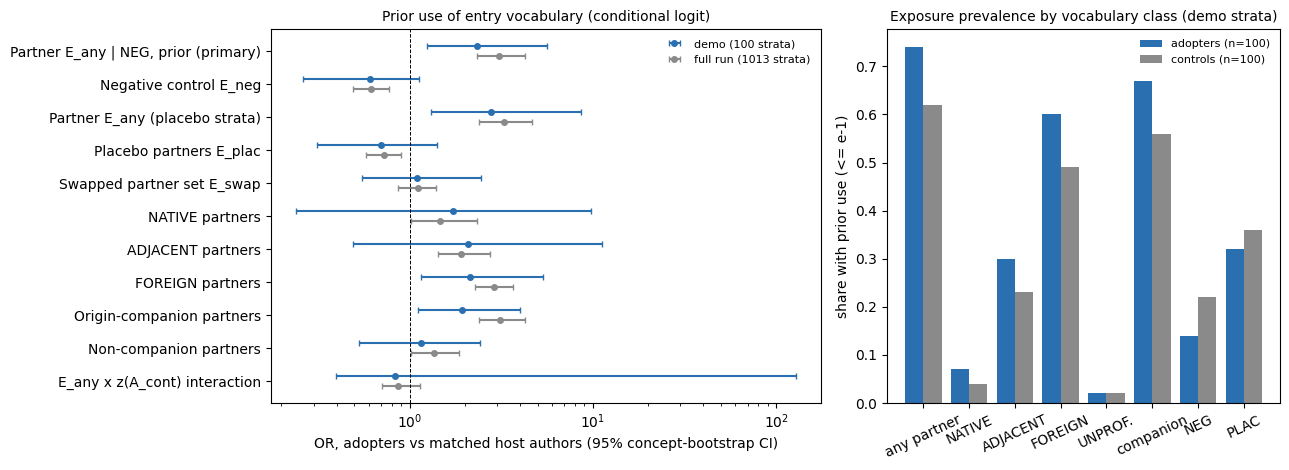

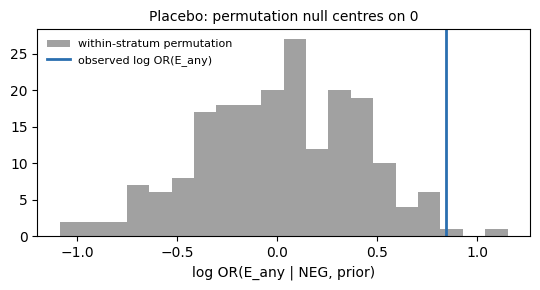

In [16]:
ref = meta["full_run_reference"]
rows = []
for lab, grp, mname, term in [("Partner E_any | NEG, prior (primary)", "enrichment", "m2", "E_any"),
                              ("Negative control E_neg", "enrichment", "m2", "E_neg"),
                              ("Partner E_any (placebo strata)", "enrichment", "m_plac", "E_any"),
                              ("Placebo partners E_plac", "enrichment", "m_plac", "E_plac"),
                              ("Swapped partner set E_swap", "enrichment", "m_swap", "E_swap"),
                              ("NATIVE partners", "vocab_class", "m_voc", "E_nat"),
                              ("ADJACENT partners", "vocab_class", "m_voc", "E_adj"),
                              ("FOREIGN partners", "vocab_class", "m_voc", "E_for"),
                              ("Origin-companion partners", "vocab_class", "m_comp", "E_comp"),
                              ("Non-companion partners", "vocab_class", "m_comp", "E_noncomp"),
                              ("E_any x z(A_cont) interaction", "interaction", "m_int", "E_any_x_zA")]:
    v = (res[grp][mname].get("terms") or {}).get(term, {})
    ci = v.get("OR_ci95_boot") or [np.nan, np.nan]
    r = ref.get(mname, {}).get(term, {})
    rci = r.get("OR_ci95_boot") or [np.nan, np.nan]
    rows.append({"term": lab, "demo_OR": v.get("OR"), "demo_lo": ci[0], "demo_hi": ci[1],
                 "full_OR": r.get("OR"), "full_lo": rci[0], "full_hi": rci[1]})
tab = pd.DataFrame(rows)
for k, r in res["ratios"].items():
    rr = ref["ratios"].get(k, {})
    print(f"ratio {k:34s} demo {r['ratio']:.2f} {np.round(r['ci95_boot'], 2) if r['ci95_boot'] else None}"
          f" | full {rr.get('ratio', np.nan):.2f} {np.round(rr.get('ci95_boot'), 2) if rr.get('ci95_boot') else None}")
print(f"verdict: demo {res['reading']['verdict']} | full {ref['reading']}  "
      f"(demo {res['descriptives']['n_strata']} strata, B={B}; full {ref['n_strata']} strata, B={ref['B']})")
display(tab.round(2))

# F1-style forest plot (from src/figs.py) + F3-style exposure prevalence bars
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axs[0]
y = np.arange(len(tab))[::-1]
for off, pre_, col, lab in [(0.15, "demo", "#2a6fb0", f"demo ({res['descriptives']['n_strata']} strata)"),
                            (-0.15, "full", "#8a8a8a", f"full run ({ref['n_strata']} strata)")]:
    o, lo, hi = tab[f"{pre_}_OR"].to_numpy(float), tab[f"{pre_}_lo"].to_numpy(float), tab[f"{pre_}_hi"].to_numpy(float)
    ok = np.isfinite(lo)
    ax.errorbar(o[ok], y[ok] + off, xerr=[o[ok] - lo[ok], hi[ok] - o[ok]], fmt="o", color=col, ms=4, capsize=2, label=lab)
    ax.plot(o[~ok], y[~ok] + off, "o", color=col, ms=4)
ax.axvline(1, color="k", lw=0.7, ls="--")
ax.set_xscale("log")
ax.set_yticks(y)
ax.set_yticklabels(tab.term)
ax.set_xlabel("OR, adopters vs matched host authors (95% concept-bootstrap CI)")
ax.set_title("Prior use of entry vocabulary (conditional logit)", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ds = res["descriptives"]
labs = [("E_any", "any partner"), ("E_nat", "NATIVE"), ("E_adj", "ADJACENT"), ("E_for", "FOREIGN"),
        ("E_unprof", "UNPROF."), ("E_comp", "companion"), ("E_neg", "NEG"), ("E_plac", "PLAC")]
x = np.arange(len(labs))
ax = axs[1]
ax.bar(x - 0.2, [ds[f"prev_case_{k}"] for k, _ in labs], 0.4, color="#2a6fb0", label=f"adopters (n={ds['n_cases']})")
ax.bar(x + 0.2, [ds[f"prev_control_{k}"] for k, _ in labs], 0.4, color="#8a8a8a", label=f"controls (n={ds['n_controls']})")
ax.set_xticks(x)
ax.set_xticklabels([l for _, l in labs], rotation=25)
ax.set_ylabel("share with prior use (<= e-1)")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Exposure prevalence by vocabulary class (demo strata)", fontsize=10)
plt.tight_layout()
plt.show()

# permutation null vs observed primary log-OR
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(np.asarray(res["permutation"]["draws"], float), bins=20, color="#8a8a8a", alpha=0.8, label="within-stratum permutation")
ax.axvline(np.log(res["enrichment"]["m2"]["terms"]["E_any"]["OR"]), color="#2a6fb0", lw=2, label="observed log OR(E_any)")
ax.set_xlabel("log OR(E_any | NEG, prior)")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Placebo: permutation null centres on 0", fontsize=10)
plt.tight_layout()
plt.show()